<a href="https://colab.research.google.com/github/LayanJunaid/heart-disease-prediction/blob/main/01_data_loading_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q seaborn --upgrade


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print(" All libraries loaded successfully!")

c:\Users\Ruhe\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Ruhe\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


 All libraries loaded successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

col_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
             'restecg', 'thalach', 'exang', 'oldpeak',
             'slope', 'ca', 'thal', 'condition']

df = pd.read_csv('processed.cleveland.data',
                 names=col_names,
                 na_values='?')

df['condition'] = df['condition'].apply(lambda x: 1 if x > 0 else 0)

print("Dataset loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
print("=" * 55)
print("FIRST 5 ROWS:")
display(df.head())

print("\nLAST 5 ROWS:")
display(df.tail())

print("\nCOLUMN NAMES:")
print(df.columns.tolist())

FIRST 5 ROWS:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



LAST 5 ROWS:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0



COLUMN NAMES:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


In [ ]:
print("=" * 55)
print("DATA TYPES & NON-NULL COUNTS:")
print()
df.info()

DATA TYPES & NON-NULL COUNTS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    float64
 1   sex        303 non-null    float64
 2   cp         303 non-null    float64
 3   trestbps   303 non-null    float64
 4   chol       303 non-null    float64
 5   fbs        303 non-null    float64
 6   restecg    303 non-null    float64
 7   thalach    303 non-null    float64
 8   exang      303 non-null    float64
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    float64
 11  ca         299 non-null    float64
 12  thal       301 non-null    float64
 13  condition  303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
print("=" * 55)
print("STATISTICAL SUMMARY:")
print()
display(df.describe().round(2))

STATISTICAL SUMMARY:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


MISSING VALUES ANALYSIS:



,Missing Count,Missing %
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00
exang,0,0.00
oldpeak,0,0.00


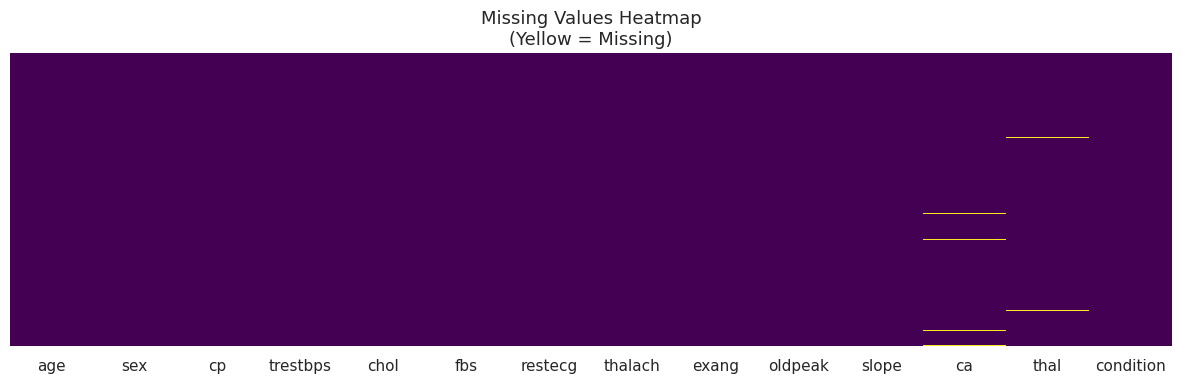


 Missing values check complete!


In [ ]:
print("=" * 55)
print("MISSING VALUES ANALYSIS:")
print()

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct
})

display(missing_df)

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False,
            cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap\n(Yellow = Missing)', fontsize=13)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()

print("\n Missing values check complete!")

TARGET VARIABLE DISTRIBUTION:

condition
0    164
1    139
Name: count, dtype: int64

Class Balance (%):
condition
0    54.1
1    45.9
Name: proportion, dtype: float64


/tmp/ipykernel_567/1185558075.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='condition', data=df,


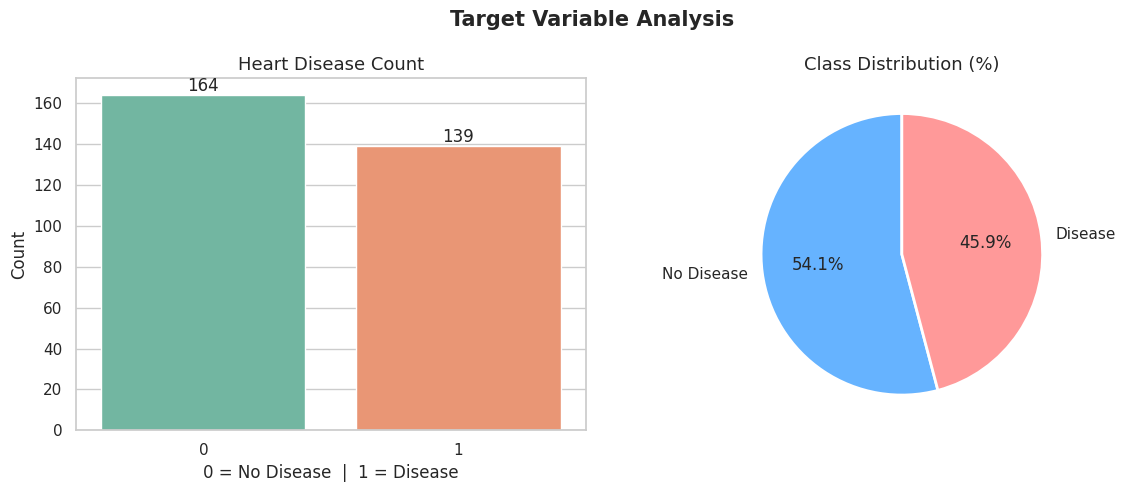

In [ ]:
print("=" * 55)
print("TARGET VARIABLE DISTRIBUTION:")
print()
print(df['condition'].value_counts())
print()
print("Class Balance (%):")
print((df['condition'].value_counts(normalize=True) * 100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='condition', data=df,
              palette='Set2', ax=axes[0],
              edgecolor='white')
axes[0].set_title('Heart Disease Count', fontsize=13)
axes[0].set_xlabel('0 = No Disease  |  1 = Disease')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

df['condition'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['No Disease', 'Disease'],
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution (%)', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

In [ ]:
feature_info = {
    'age':      ['Numerical',   'Age of patient in years'],
    'sex':      ['Categorical', '1 = Male, 0 = Female'],
    'cp':       ['Categorical', 'Chest pain type: 0=Typical, 1=Atypical, 2=Non-anginal, 3=Asymptomatic'],
    'trestbps': ['Numerical',   'Resting blood pressure (mmHg)'],
    'chol':     ['Numerical',   'Serum cholesterol (mg/dl)'],
    'fbs':      ['Categorical', 'Fasting blood sugar > 120mg/dl: 1=True, 0=False'],
    'restecg':  ['Categorical', 'Resting ECG results: 0=Normal, 1=ST-T abnormality, 2=LV hypertrophy'],
    'thalach':  ['Numerical',   'Maximum heart rate achieved'],
    'exang':    ['Categorical', 'Exercise induced angina: 1=Yes, 0=No'],
    'oldpeak':  ['Numerical',   'ST depression induced by exercise relative to rest'],
    'slope':    ['Categorical', 'Slope of peak exercise ST segment: 0=Up, 1=Flat, 2=Down'],
    'ca':       ['Categorical', 'Number of major vessels colored by fluoroscopy (0-3)'],
    'thal':     ['Categorical', 'Thalassemia: 0=Normal, 1=Fixed defect, 2=Reversible defect'],
    'condition':['TARGET',      '0 = No Heart Disease | 1 = Heart Disease Present']
}

desc_df = pd.DataFrame.from_dict(
    feature_info, orient='index',
    columns=['Type', 'Description']
)
desc_df.index.name = 'Feature'

print("FEATURE DESCRIPTIONS:")
display(desc_df)

FEATURE DESCRIPTIONS:


,Type,Description
Feature,,
age,Numerical,Age of patient in years
sex,Categorical,"1 = Male, 0 = Female"
cp,Categorical,"Chest pain type: 0=Typical, 1=Atypical, 2=Non-..."
trestbps,Numerical,Resting blood pressure (mmHg)
chol,Numerical,Serum cholesterol (mg/dl)
fbs,Categorical,"Fasting blood sugar > 120mg/dl: 1=True, 0=False"
restecg,Categorical,"Resting ECG results: 0=Normal, 1=ST-T abnormal..."
thalach,Numerical,Maximum heart rate achieved
exang,Categorical,"Exercise induced angina: 1=Yes, 0=No"
